# 05-Enterprise Backbones

In Lesson 04, we architected our very first Convolutional Neural Network from scratch. We manually calculated the spatial dimensions, constructed the Feature Extractor, and built the flattening bridge.

For simple, low-resolution datasets (like $64 \times 64$ coffee cups), a custom 3-layer CNN works perfectly. But what if you are tasked with classifying high-resolution $224 \times 224$ images across 1,000 different complex real-world categories?

Your custom 3-layer CNN will completely fail. It lacks the mathematical capacity and Receptive Field required to comprehend complex objects. To solve enterprise-grade problems, we do not build architectures from scratch. We stand on the shoulders of giants. We utilize **Enterprise Backbones**—state-of-the-art neural architectures engineered by researchers at Google, Microsoft, and Oxford, mathematically optimized for deep spatial learning.

Let's set up our PyTorch environment to import the titans of Computer Vision.

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Enterprise Vision Backbones Ready.")

✅ PyTorch Enterprise Vision Backbones Ready.


# 1. VGG-16 (The Deep & Uniform Paradigm)

In 2014, researchers at Oxford (the Visual Geometry Group) introduced **VGG-16**. Before VGG, engineers used massive kernels ($11 \times 11$ or $7 \times 7$) in their early layers to capture large receptive fields, which was computationally disastrous.

VGG introduced a brilliant mathematical simplification: **Stacking small kernels is strictly superior to using one large kernel.**

If you stack two $3 \times 3$ convolutions on top of each other, the resulting Receptive Field is exactly $5 \times 5$. But doing this has two massive mathematical advantages:

1. **Fewer Parameters**: A $5 \times 5$ kernel requires 25 weights. Two $3 \times 3$ kernels require $9 + 9 = 18$ weights. You achieve the exact same field of view using 28% less memory.
2. **More Non-Linearity**: By splitting the operation into two layers, you can insert two `ReLU` activations instead of just one, allowing the network to learn vastly more complex geometric curves.

* **The Flaw**: VGG-16 is uniform and beautiful, but it is astronomically heavy. It requires **138 Million parameters**, mostly locked up in the massive Dense layers at the very end of the network.

# 2. The Degradation Problem (The Wall)

After VGG, researchers assumed the secret to better AI was simply adding more layers. If 16 layers is good, 50 layers must be better!

They hit a mathematical brick wall called the **Degradation Problem**. When you stack 50 standard Convolutional layers, the Training Error *increases*. This is not Overfitting (where training error drops but validation increases); the network simply fails to learn at all.

Why? Because of **Vanishing Gradients**. By the time the calculus derivative (the error signal) chain-rules its way backward through 50 layers of matrix multiplications and ReLUs, the gradient has decayed to absolute zero. The early layers receive no feedback and never get updated.

# 3. ResNet (The Skip Connection Revolution)

In 2015, Kaiming He (Microsoft Research) solved the Degradation Problem and revolutionized Deep Learning forever with **ResNet (Residual Networks)**.

He introduced a shockingly simple architectural hack: **The Skip Connection** (or Shortcut).
Instead of forcing the data to flow strictly sequentially through every single layer ($F(x)$), ResNet draws a physical, mathematical wire that bypasses the convolutional block and adds the original input back to the output of the block.

$$H(x) = F(x) + x$$

### The Calculus of the Skip Connection

Why does adding $+ x$ fix a 50-layer network?
During Forward Propagation, the network learns the "residual" difference between the input and the target. But the true magic happens during Backpropagation.
When calculating the derivative of $F(x) + x$, the derivative of $x$ is exactly $1$.
This creates an unobstructed **Gradient Superhighway**. No matter how deep the network is, the gradient can instantly bypass the complex matrix multiplications and flow cleanly all the way back to Layer 1.

# 4. EfficientNet (The Mathematics of Compound Scaling)

By 2019, Google researchers asked a new question: If we want to make a network smarter, should we make it Deeper (more layers), Wider (more filters per layer), or feed it Higher Resolution images?

Historically, engineers just guessed. EfficientNet proved mathematically that you must scale all three simultaneously. If you use a high-resolution image, you *must* increase the Receptive Field (Depth) to see the larger object, and you *must* increase the capacity (Width) to capture the finer details.

EfficientNet uses a single mathematical constant, the **Compound Coefficient ($\phi$)**, to perfectly scale Depth, Width, and Resolution in unison.

# 5. Visualizing Deep Semantics in PyTorch

Let's load a pretrained ResNet-18. We will pass a high-resolution image of a rocket launch through the network and physically intercept the tensors at Layer 1 (Shallow) and Layer 4 (Deep) to see how the mathematical abstraction evolves.

--- 📥 Downloading Pretrained ResNet-18 ---
Input Tensor Shape: torch.Size([1, 3, 224, 224])

--- 🧠 Executing the Forward Pass & Intercepting Tensors ---
Shallow Tensor (Layer 1): torch.Size([1, 64, 56, 56])
Deep Tensor (Layer 4):    torch.Size([1, 512, 7, 7])


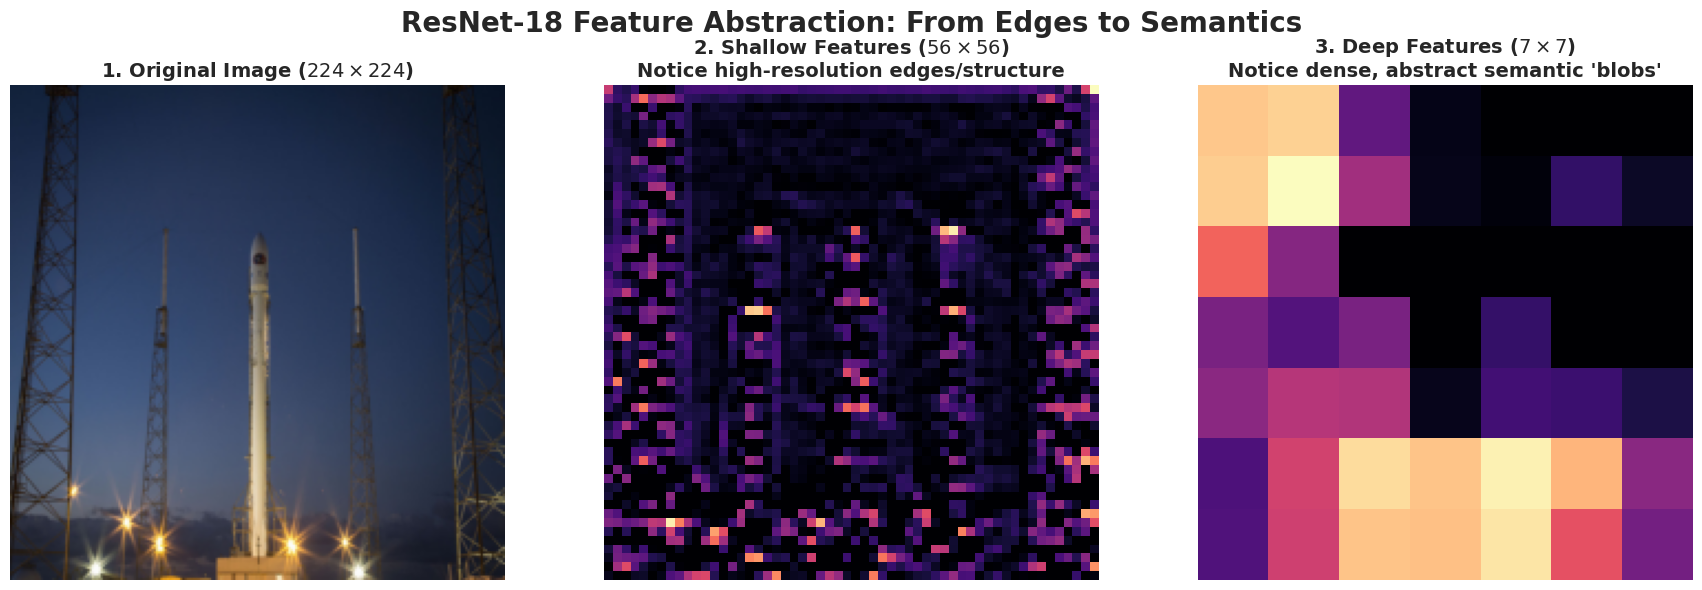

--- 💡 Architectural Insight ---
Look at the transformation. In Plot 2, the Receptive Field is still relatively small. The network clearly highlights the physical, high-resolution edges of the exhaust plume and the rocket boosters. But by Plot 3, the spatial dimensions have been utterly crushed down to a 7x7 grid. The network no longer sees 'edges'. Every single pixel in that 7x7 grid contains a massively deep 512-dimensional vector that represents highly abstract, holistic concepts like 'This quadrant of the image contains thermodynamics/fire'.


In [4]:
# 1. Load the Pretrained Enterprise Backbone
print("--- 📥 Downloading Pretrained ResNet-18 ---")
# We load the exact weights mathematically optimized on the ImageNet dataset
weights = models.ResNet18_Weights.IMAGENET1K_V1
resnet = models.resnet18(weights=weights)
resnet.eval() # Set to evaluation mode (disables Dropout/BatchNorm updates)

# 2. Fetch and Format the Real Image
numpy_rocket = data.rocket()

# ImageNet architectures STRICTLY require this specific normalization pipeline
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # The mathematical means and standard deviations of the ImageNet dataset
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

rocket_tensor = preprocess(numpy_rocket).unsqueeze(0)
print(f"Input Tensor Shape: {rocket_tensor.shape}")

# 3. Intercepting the Network Geometry
print("\n--- 🧠 Executing the Forward Pass & Intercepting Tensors ---")
with torch.no_grad():
    # A. Shallow Features: Pass through Conv1, BatchNorm, ReLU, and MaxPool
    x = resnet.conv1(rocket_tensor)
    x = resnet.bn1(x)
    x = resnet.relu(x)
    x = resnet.maxpool(x)
    
    # Pass through the first Residual Block (Layer 1)
    shallow_features = resnet.layer1(x)
    print(f"Shallow Tensor (Layer 1): {shallow_features.shape}")
    
    # B. Deep Features: Pass through the remaining Residual Blocks
    x = resnet.layer2(shallow_features)
    x = resnet.layer3(x)
    deep_features = resnet.layer4(x)
    print(f"Deep Tensor (Layer 4):    {deep_features.shape}")

# 4. Visualizing the Abstraction Hierarchy
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("ResNet-18 Feature Abstraction: From Edges to Semantics", fontsize=20, fontweight='bold')

# Plot A: Original (Resized for network)
axes[0].imshow(transforms.Resize((224,224))(transforms.ToPILImage()(numpy_rocket)))
axes[0].set_title("1. Original Image ($224 \\times 224$)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: Shallow Feature Map (Layer 1)
# We pick a random channel (e.g., channel 12 out of 64) to visualize
shallow_map = shallow_features[0, 12, :, :].numpy()
axes[1].imshow(shallow_map, cmap='magma')
axes[1].set_title(f"2. Shallow Features ($56 \\times 56$)\nNotice high-resolution edges/structure", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: Deep Feature Map (Layer 4)
# We pick a random channel (e.g., channel 200 out of 512)
deep_map = deep_features[0, 200, :, :].numpy()
# We use interpolation='nearest' to clearly show the 7x7 grid blocks
axes[2].imshow(deep_map, cmap='magma', interpolation='nearest')
axes[2].set_title(f"3. Deep Features ($7 \\times 7$)\nNotice dense, abstract semantic 'blobs'", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("--- 💡 Architectural Insight ---")
print("Look at the transformation. In Plot 2, the Receptive Field is still relatively small. The network clearly highlights the physical, high-resolution edges of the exhaust plume and the rocket boosters. But by Plot 3, the spatial dimensions have been utterly crushed down to a 7x7 grid. The network no longer sees 'edges'. Every single pixel in that 7x7 grid contains a massively deep 512-dimensional vector that represents highly abstract, holistic concepts like 'This quadrant of the image contains thermodynamics/fire'.")

## Real-World Use Case or Analogy:

Think of Enterprise Backbones like **Corporate Communication Structures**:

* **Standard Deep CNN (The Bureaucracy)**: A Junior Field Analyst (Layer 1) finds a critical error. They pass the report to their Manager (Layer 2), who passes it to the Director (Layer 3), who passes it to the VP (Layer 4). By the time the report reaches the CEO (Layer 50), the message has been distorted, compressed, and summarized so many times through matrix multiplications that the core warning is completely lost. The CEO takes no action (Vanishing Gradient).
* **ResNet (The CC: CEO Email Rule)**: Microsoft restructures the company. The chain of command still exists to process complex, layered work ($F(x)$). However, there is a new strict rule: Every time you send a report to your boss, you are required to CC the CEO ($+ x$). Even if the middle managers completely ruin the main report, the CEO receives a mathematically perfect copy of the raw data. If the CEO needs to send instructions backward (Backpropagation), they don't rely on the managers; they reply directly to the Junior Analyst via the CC thread. The company can now seamlessly scale to 152 layers of management without losing the signal!